In [1]:
import os
import time
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchinfo import summary
sys.path.append(str(Path.cwd().parent))
from helper import normalize, denormalize, train_model, get_normalized_data, evaluate_model, denormalize_std
import argparse
import jammy_flows
from scipy.stats import norm
import helper
import models as m
import normalizing_flow as flow

torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *astropy* not found -> if you want to use plotting functionality for adaptive grids, install *astropy*!
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!


In [2]:
import importlib
importlib.reload(helper)
importlib.reload(m)
importlib.reload(flow)

<module 'normalizing_flow' from '/mnt/shared/Uni/Master_2/Deep-Learning/normalizing_flow.py'>

In [3]:
DATA_PATH = "./data_galah4"
fp64_on_cpu = False

# path for plots
PLOT_PATH = "./plots_ex3"
os.makedirs(PLOT_PATH, exist_ok=True)

# Hyperparameters
learning_rate = 0.8e-5
batch_size = 32
epochs = 200
patience = 10

training_split = 0.7
validation_split = 0.15

normalizing_flow_type = ["diagonal_gaussian", "full_gaussian", "full_flow"]

# Call the function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH) 


In [4]:
## load data
# convert to tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# split into training, validation, and test sets
sample_size = len(spectra_tensor)
train_size = int(training_split * sample_size)
val_size = int(validation_split * sample_size)
test_size = sample_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(67))

# create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [5]:
MODEL_PATH = f"./models"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

for nf_type in normalizing_flow_type:
    model = flow.CombinedModel(m.CNN_Astronomy, nf_type=nf_type)
    summary(model, input_size=(1, 1, spectra_length))
    model.to(device)
    train_losses, val_losses, best_model_state = train_model(model, train_loader, val_loader, flow.nf_loss,learning_rate, epochs, patience, device)

    model.load_state_dict(best_model_state)
    torch.save(best_model_state, MODEL_PATH + f"/{nf_type}.pth")

    np.savez(f"./models/{nf_type}_losses.npz", train=train_losses, val=val_losses)

The normalizing flow has  6  parameters...


/home/freddy/miniforge3/envs/deep-learning/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


Epoch [1/200], Step [190/195], Loss: 0.5853
Epoch [1/200], Train Loss: 1.9621, Val Loss: 0.6803, Time: 3.81 seconds
Epoch [2/200], Step [190/195], Loss: 0.6029
Epoch [2/200], Train Loss: 0.6145, Val Loss: -0.1545, Time: 3.63 seconds
Epoch [3/200], Step [190/195], Loss: 0.12230
Epoch [3/200], Train Loss: 0.1958, Val Loss: -0.6262, Time: 3.64 seconds
Epoch [4/200], Step [190/195], Loss: 0.04809
Epoch [4/200], Train Loss: -0.0935, Val Loss: -1.0158, Time: 3.63 seconds
Epoch [5/200], Step [190/195], Loss: -0.1577
Epoch [5/200], Train Loss: -0.2633, Val Loss: -1.1118, Time: 3.72 seconds
Epoch [6/200], Step [190/195], Loss: -0.6374
Epoch [6/200], Train Loss: -0.4345, Val Loss: -1.2918, Time: 3.63 seconds
Epoch [7/200], Step [190/195], Loss: -0.7703
Epoch [7/200], Train Loss: -0.6034, Val Loss: -1.5871, Time: 3.71 seconds
Epoch [8/200], Step [190/195], Loss: -0.9918
Epoch [8/200], Train Loss: -0.7560, Val Loss: -1.6992, Time: 3.47 seconds
Epoch [9/200], Step [190/195], Loss: -0.8717
Epoch [9/


=== Evaluating diagonal_gaussian ===
The normalizing flow has  6  parameters...
Evaluating model on the test dataset...


<>:106: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\s'
<>:106: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_42460/2016899558.py:106: SyntaxWarning: invalid escape sequence '\m'
  label=f"Pulls ($\mu={mu:.2f}$, $\sigma={sigma:.2f}$)")
/tmp/ipykernel_42460/2016899558.py:106: SyntaxWarning: invalid escape sequence '\s'
  label=f"Pulls ($\mu={mu:.2f}$, $\sigma={sigma:.2f}$)")
/tmp/ipykernel_42460/2016899558.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be 

Final Test Loss: -3.8273

=== Evaluating full_gaussian ===
The normalizing flow has  9  parameters...
Evaluating model on the test dataset...
Final Test Loss: -2.6838

=== Evaluating full_flow ===
The normalizing flow has  306  parameters...
Evaluating model on the test dataset...
Final Test Loss: -4.0310


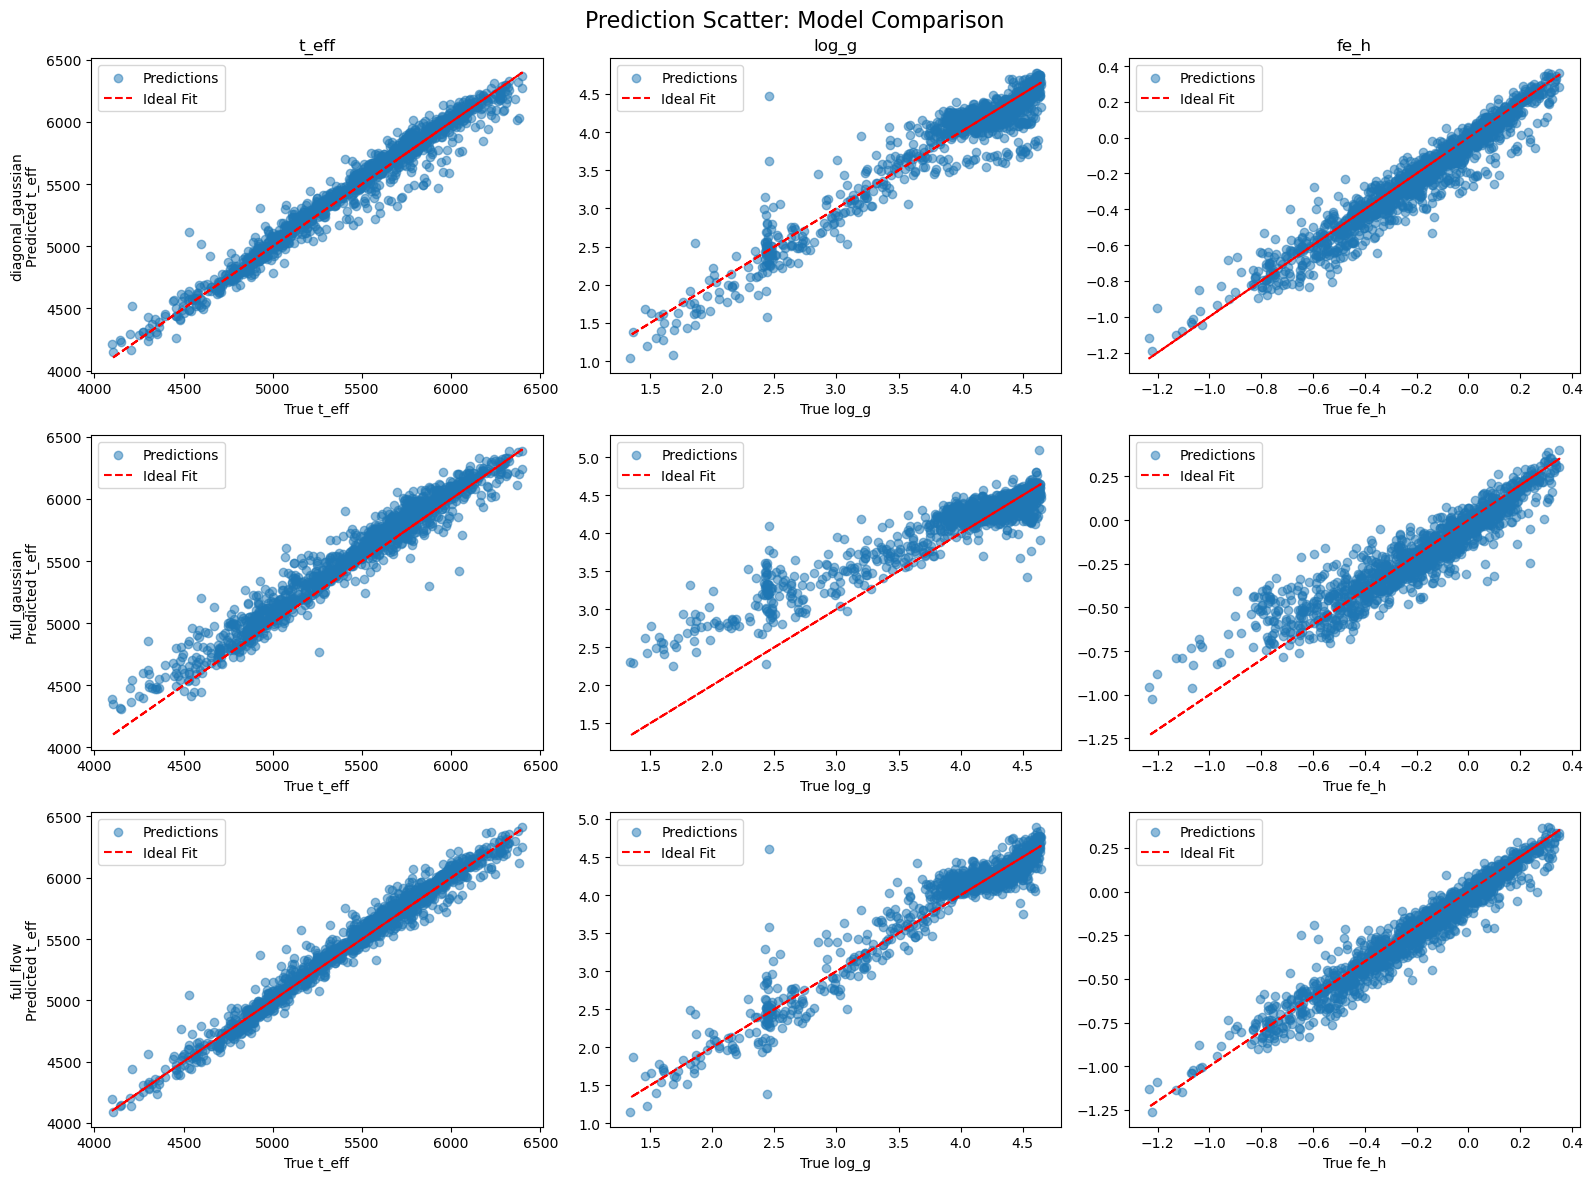

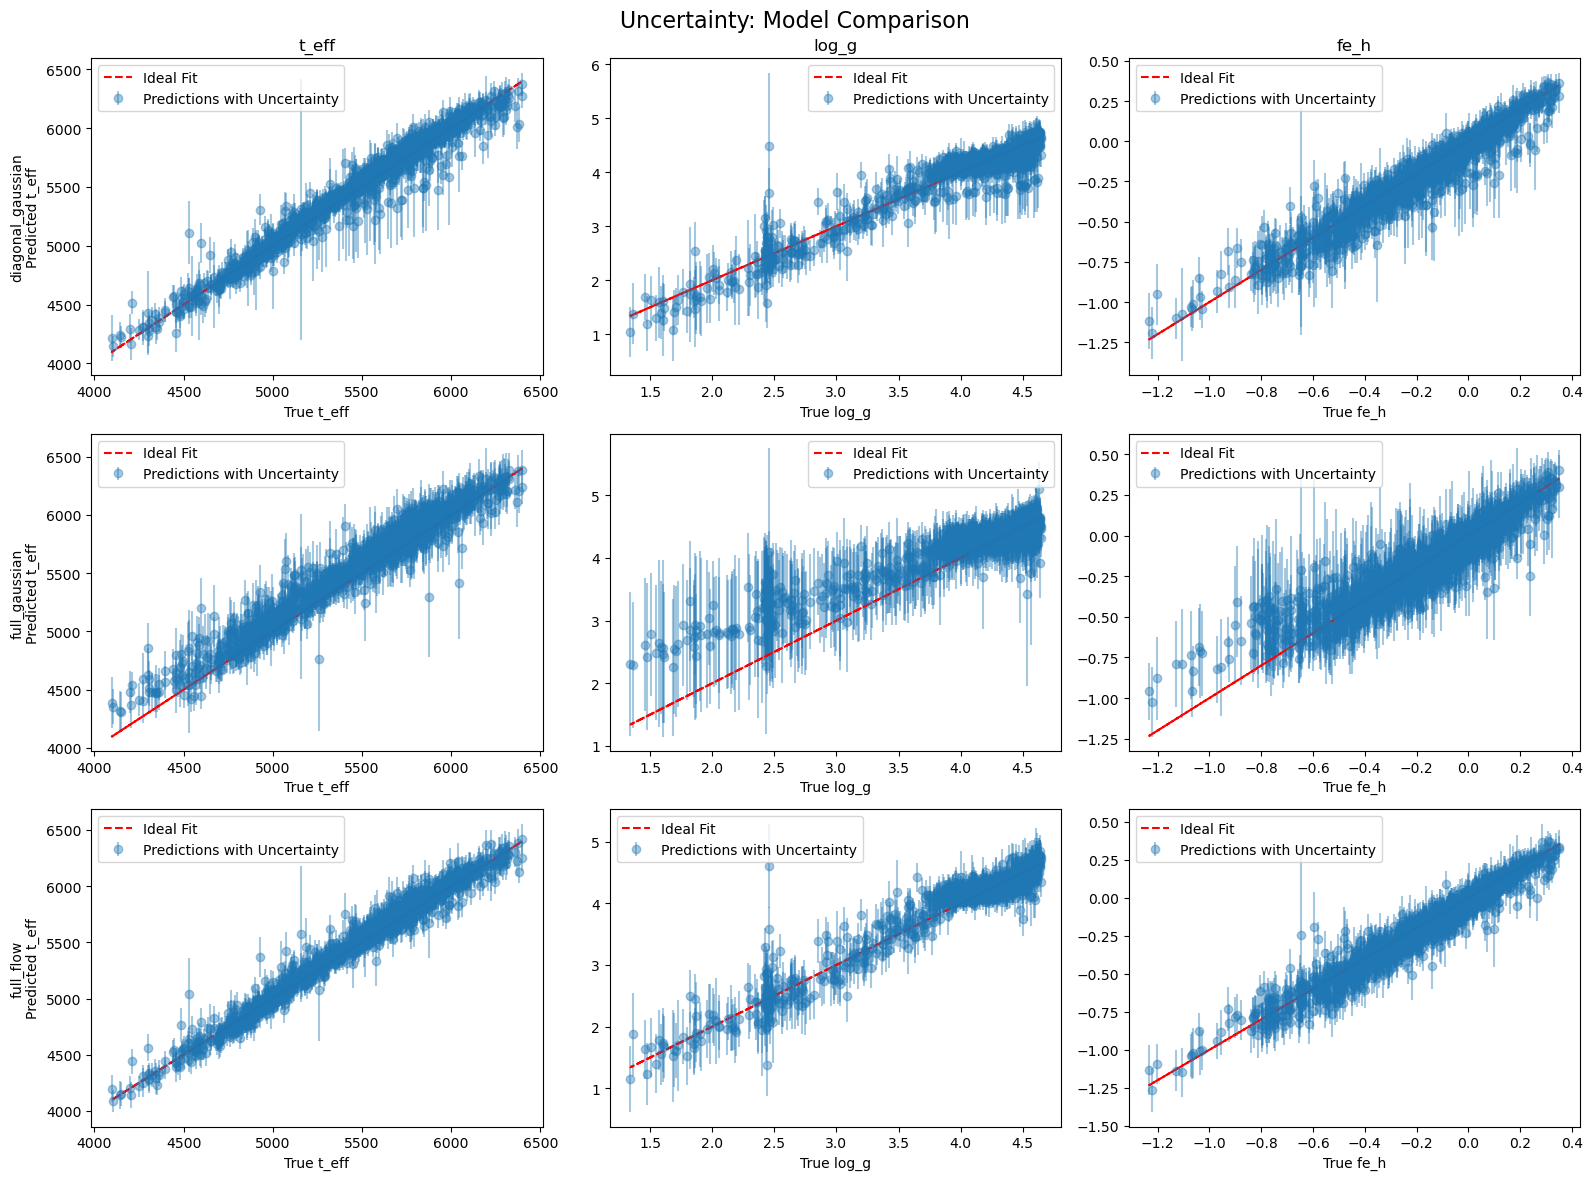

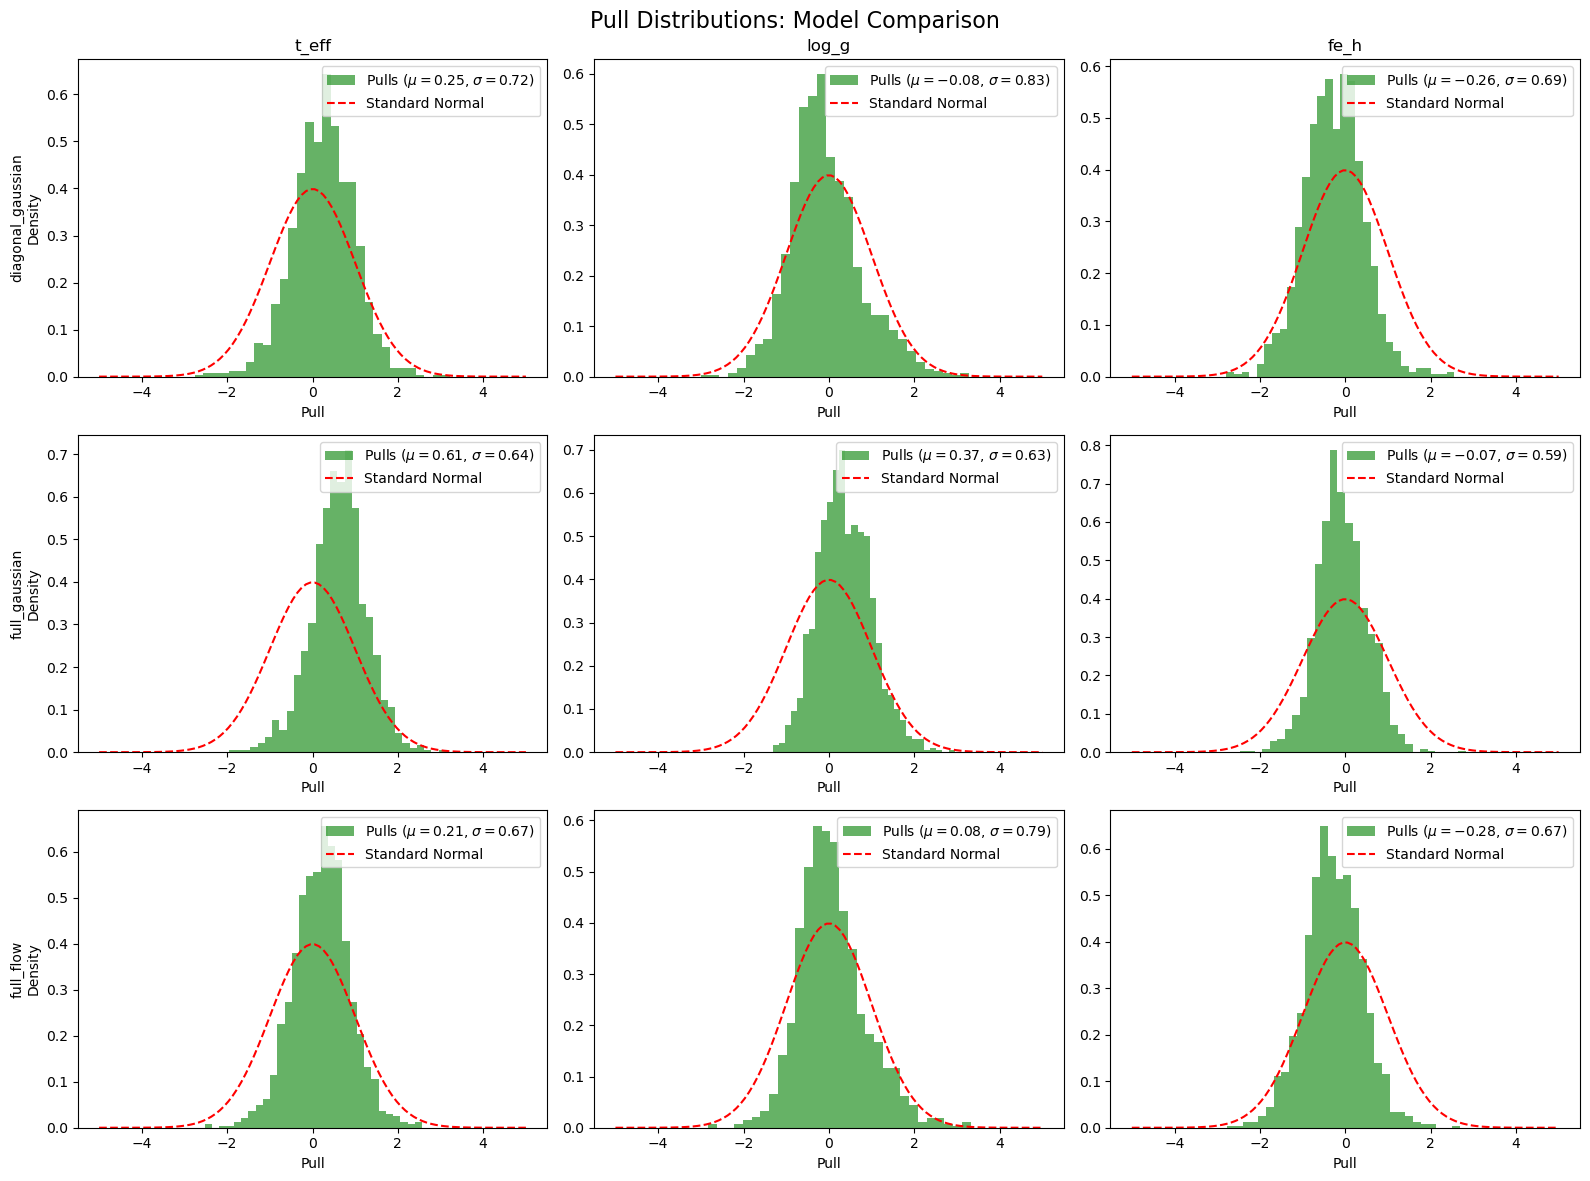

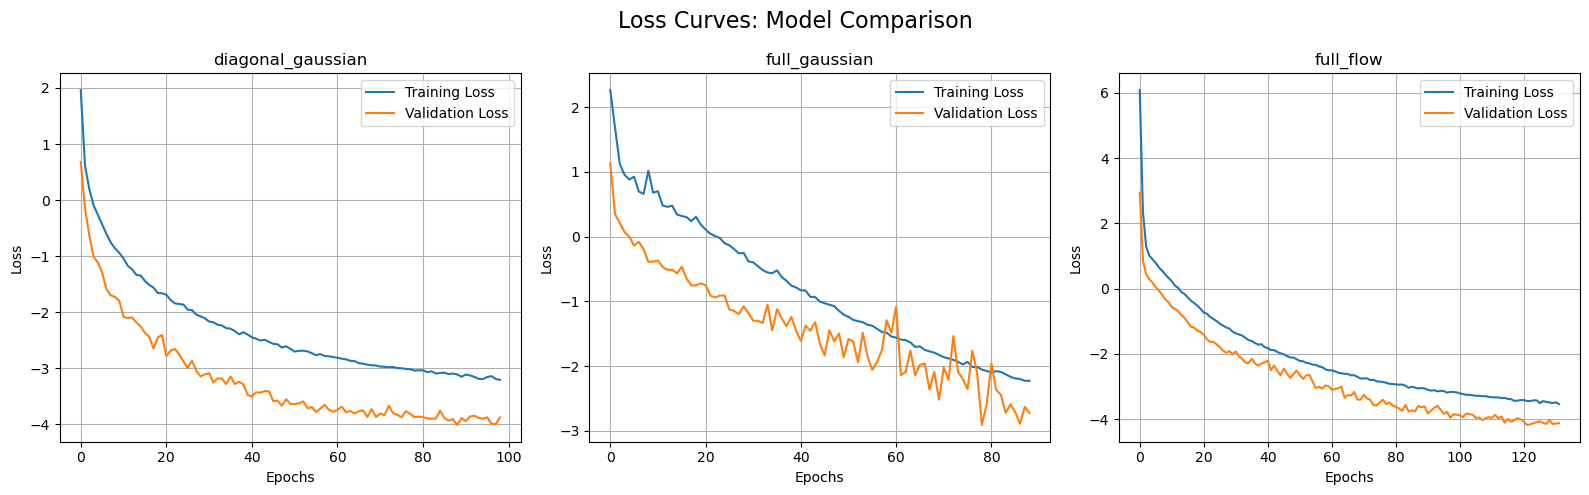

In [6]:
nf_types = ["diagonal_gaussian", "full_gaussian", "full_flow"]

# ==========================================
# 1. DATA COLLECTION
# ==========================================
model_results = {}

for nf_type in nf_types:
    print(f"\n=== Evaluating {nf_type} ===")

    # Recreate model with matching flow type and load trained weights
    model = flow.CombinedModel(m.CNN_Astronomy, nf_type=nf_type)
    model.load_state_dict(torch.load(f"models/{nf_type}.pth", map_location=device))
    model.to(device)
    model.eval() # Always good practice for evaluation!

    with torch.no_grad():
        all_predictions, all_true_labels, _, _ = evaluate_model(model, test_loader, flow.nf_loss, device)

    # Denormalize predictions and labels
    all_predictions[:, :n_labels] = denormalize(all_predictions[:, :n_labels], ranges[:n_labels])
    normalized_std = all_predictions[:, n_labels:]
    denormalized_std = denormalize_std(normalized_std, ranges)
    all_predictions[:, n_labels:] = denormalized_std
    all_true_labels = denormalize(all_true_labels, ranges)

    losses = np.load(f"./models/{nf_type}_losses.npz")
    
    # Store results for plotting
    model_results[nf_type] = {
        "preds": all_predictions,
        "true": all_true_labels,
        "train_losses": losses['train'],
        "val_losses": losses['val']
    }

# ==========================================
# 2. COMBINED PLOTTING
# ==========================================
n_models = len(nf_types)

# --- A. Combined Scatter Plot ---
fig_scatter, axes_scatter = plt.subplots(nrows=n_models, ncols=n_labels, figsize=(16, 12))
for i, nf_type in enumerate(nf_types):
    preds = model_results[nf_type]["preds"]
    true = model_results[nf_type]["true"]
    
    for j in range(n_labels):
        ax = axes_scatter[i, j]
        ax.scatter(true[:, j], preds[:, j], label="Predictions", alpha=0.5)
        ax.plot(true[:, j], true[:, j], "r--", label="Ideal Fit")
        
        # Formatting
        ax.set_xlabel(f"True {labelNames[j]}")
        if j == 0: ax.set_ylabel(f"{nf_type}\nPredicted {labelNames[j]}")
        if i == 0: ax.set_title(f"{labelNames[j]}")
        ax.legend()
        
fig_scatter.suptitle("Prediction Scatter: Model Comparison", fontsize=16)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/combined_scatter.png")
plt.show()


# --- B. Combined Uncertainty Plot ---
fig_uncert, axes_uncert = plt.subplots(nrows=n_models, ncols=n_labels, figsize=(16, 12))
for i, nf_type in enumerate(nf_types):
    preds = model_results[nf_type]["preds"]
    true = model_results[nf_type]["true"]
    
    for j in range(n_labels):
        ax = axes_uncert[i, j]
        std_for_plot = preds[:, n_labels + j]
        ax.errorbar(
            true[:, j], preds[:, j], yerr=std_for_plot,
            fmt="o", label="Predictions with Uncertainty", alpha=0.4
        )
        ax.plot(true[:, j], true[:, j], "r--", label="Ideal Fit")
        
        # Formatting
        ax.set_xlabel(f"True {labelNames[j]}")
        if j == 0: ax.set_ylabel(f"{nf_type}\nPredicted {labelNames[j]}")
        if i == 0: ax.set_title(f"{labelNames[j]}")
        ax.legend()
        
fig_uncert.suptitle("Uncertainty: Model Comparison", fontsize=16)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/combined_uncertainty.png")
plt.show()


# --- C. Combined Pulls Distribution ---
fig_pulls, axes_pulls = plt.subplots(nrows=n_models, ncols=n_labels, figsize=(16, 12))
for i, nf_type in enumerate(nf_types):
    preds = model_results[nf_type]["preds"]
    true = model_results[nf_type]["true"]
    
    for j in range(n_labels):
        ax = axes_pulls[i, j]
        
        pulls = (preds[:, j] - true[:, j]) / preds[:, n_labels + j]
        mu = np.mean(pulls)
        sigma = np.std(pulls)
        
        ax.hist(pulls, bins=30, density=True, alpha=0.6, color="g", 
                label=f"Pulls ($\mu={mu:.2f}$, $\sigma={sigma:.2f}$)")
        
        x = np.linspace(-5, 5, 100)
        ax.plot(x, norm.pdf(x), "r--", label="Standard Normal")
        
        # Formatting
        ax.set_xlabel("Pull")
        if j == 0: ax.set_ylabel(f"{nf_type}\nDensity")
        if i == 0: ax.set_title(f"{labelNames[j]}")
        ax.legend(loc="upper right")
        
fig_pulls.suptitle("Pull Distributions: Model Comparison", fontsize=16)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/combined_pulls.png")
plt.show()


# --- D. Combined Loss Curves ---
fig_losses, axes_losses = plt.subplots(nrows=1, ncols=n_models, figsize=(16, 5))
for i, nf_type in enumerate(nf_types):
    ax = axes_losses[i]
    
    # Ideally, replace these with: losses_dict[nf_type]['train_losses']
    ax.plot(model_results[nf_type]["train_losses"], label="Training Loss") 
    ax.plot(model_results[nf_type]["val_losses"], label="Validation Loss")
    
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.set_title(f"{nf_type}")
    ax.legend()
    ax.grid()
    
fig_losses.suptitle("Loss Curves: Model Comparison", fontsize=16)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/combined_losses.png")
plt.show()

In [7]:
spectra_batch, labels_batch = next(iter(test_loader))

# Move the data to the correct device
spectra_batch = spectra_batch.to(device)
labels_batch = labels_batch.to(device)

if len(spectra_batch.shape) == 2:
    spectra_batch = spectra_batch.unsqueeze(1)

batch_idx = 0 
truth_values = labels_batch[batch_idx] # Extract the specific true labels for that item

for nf_type in normalizing_flow_type:
    print(f"Generating PDF plot for: {nf_type}")
    
    # Initialize the model architecture
    current_model = flow.CombinedModel(m.CNN_Astronomy, nf_type=nf_type)
    current_model.to(device)
    
    # Load the trained weights
    model_path = f"./models/{nf_type}.pth"
    
    if os.path.exists(model_path):
        current_model.load_state_dict(torch.load(model_path, map_location=device))
        current_model.eval() # Set to evaluation mode (important for BatchNorm/Dropout)
        
        # Create a filename for the plot
        plot_filename = f"{PLOT_PATH}/{nf_type}_example_pdf.png"
        
        # Call your visualization function
        with torch.no_grad(): # No need to track gradients just for plotting
            current_model.visualize_pdf(
                input_data=spectra_batch, 
                filename=plot_filename, 
                batch_index=batch_idx, 
                truth=truth_values
            )
        print(f"Saved -> {plot_filename}")

Generating PDF plot for: diagonal_gaussian
The normalizing flow has  6  parameters...
Saved -> ./plots_ex3/diagonal_gaussian_example_pdf.png
Generating PDF plot for: full_gaussian
The normalizing flow has  9  parameters...


/tmp/ipykernel_42460/2126024353.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  current_model.load_state_dict(torch.load(model_path, map_location=device))


Saved -> ./plots_ex3/full_gaussian_example_pdf.png
Generating PDF plot for: full_flow
The normalizing flow has  306  parameters...
Saved -> ./plots_ex3/full_flow_example_pdf.png
